# Yield Curve Decomposer

This lab uses **principal component analysis (PCA)** to reduce five Treasury-rate movements into a few common factors: Level, Slope, and Curvature.

### Imports

- `numpy` performs matrix calculations and SVD.
- `pandas` stores and cleans the yield data.
- `matplotlib` and `seaborn` create the graphs.
- `urlencode` safely constructs the FRED download URL.

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from urllib.parse import urlencode

### 1. Analysis Settings

The sample begins in 2016 and ends on the current date.

`TENORS` connects each maturity to its FRED series and numerical maturity. We use 1Y, 2Y, 5Y, 10Y, and 30Y Treasury yields as a public proxy for an interest-rate curve.

`TARGET_VARIANCE = 0.95` sets our main test: can the first three components explain at least 95% of daily curve variation?

In [19]:
START_DATE = "2016-01-01"
END_DATE = pd.Timestamp.today().strftime("%Y-%m-%d")

TENORS = {
    "1Y": {"years": 1, "fred_id": "DGS1"},
    "2Y": {"years": 2, "fred_id": "DGS2"},
    "5Y": {"years": 5, "fred_id": "DGS5"},
    "10Y": {"years": 10, "fred_id": "DGS10"},
    "30Y": {"years": 30, "fred_id": "DGS30"},
}

tenor_labels = list(TENORS.keys())
tenor_years = np.array([
    TENORS[tenor]["years"]
    for tenor in tenor_labels
])

TARGET_VARIANCE = 0.95

### 2. Download and Organize the Yield Data

`download_fred_series()`:

1. Builds a FRED URL for one series.
2. Downloads the CSV data.
3. Converts the date column into a datetime index.
4. Converts the yield observations into numbers.
5. Returns the cleaned time series.

The loop runs this function for every maturity. `pd.concat(..., axis=1)` joins the five series as columns.

`dropna(how="any")` keeps only dates where all five yields are available.

The result contains 2,662 dates and five maturities. Yields remain in percentage points, so `4.00` means 4.00%.

In [20]:
def download_fred_series(series_id, start_date, end_date):
    query = urlencode({
        "id": series_id,
        "cosd": start_date,
        "coed": end_date,
    })

    url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?{query}"

    series = pd.read_csv(
        url,
        na_values=["."]
    )

    # FRED may call the first column "observation_date"
    # instead of "DATE".
    date_column = series.columns[0]

    series = series.rename(
        columns={date_column: "DATE"}
    )

    series["DATE"] = pd.to_datetime(
        series["DATE"]
    )

    series = series.set_index("DATE")

    series[series_id] = pd.to_numeric(
        series[series_id],
        errors="coerce"
    )

    return series


curve_series = []

for tenor, information in TENORS.items():
    fred_id = information["fred_id"]

    series = download_fred_series(
        series_id=fred_id,
        start_date=START_DATE,
        end_date=END_DATE,
    )

    series = series.rename(
        columns={fred_id: tenor}
    )

    curve_series.append(series)


yields_pct = pd.concat(
    curve_series,
    axis=1
)

yields_pct = (
    yields_pct[tenor_labels]
    .dropna(how="any")
    .sort_index()
)

print("First date:", yields_pct.index.min().date())
print("Last date:", yields_pct.index.max().date())
print("Number of complete observations:", len(yields_pct))

display(yields_pct.head())
display(yields_pct.tail())

First date: 2016-01-04
Last date: 2026-08-25
Number of complete observations: 2662


,1Y,2Y,5Y,10Y,30Y
DATE,,,,,
2016-01-04,0.61,1.02,1.73,2.24,2.98
2016-01-05,0.68,1.04,1.73,2.25,3.01
2016-01-06,0.67,0.99,1.65,2.18,2.94
2016-01-07,0.66,0.96,1.61,2.16,2.92
2016-01-08,0.64,0.94,1.57,2.13,2.91


,1Y,2Y,5Y,10Y,30Y
DATE,,,,,
2026-08-19,4.00,4.19,4.35,4.65,5.19
2026-08-20,3.99,4.19,4.39,4.69,5.23
2026-08-21,4.03,4.24,4.43,4.74,5.27
2026-08-24,4.04,4.24,4.41,4.70,5.23
2026-08-25,4.01,4.17,4.35,4.64,5.17


### 3. Plot Yield Levels Through Time

Each line shows the historical yield for one Treasury maturity.

The maturities generally move together, suggesting that a common **Level factor** drives much of the curve.

The graph also shows changes in shape. Short-term yields fell close to zero in 2020 and then rose faster than long-term yields during 2022–2023. When different maturities move by different amounts, the curve's Slope or Curvature changes.

This graph displays yield **levels**. The PCA will use daily **changes** because we want to explain how the curve moves from one day to the next.

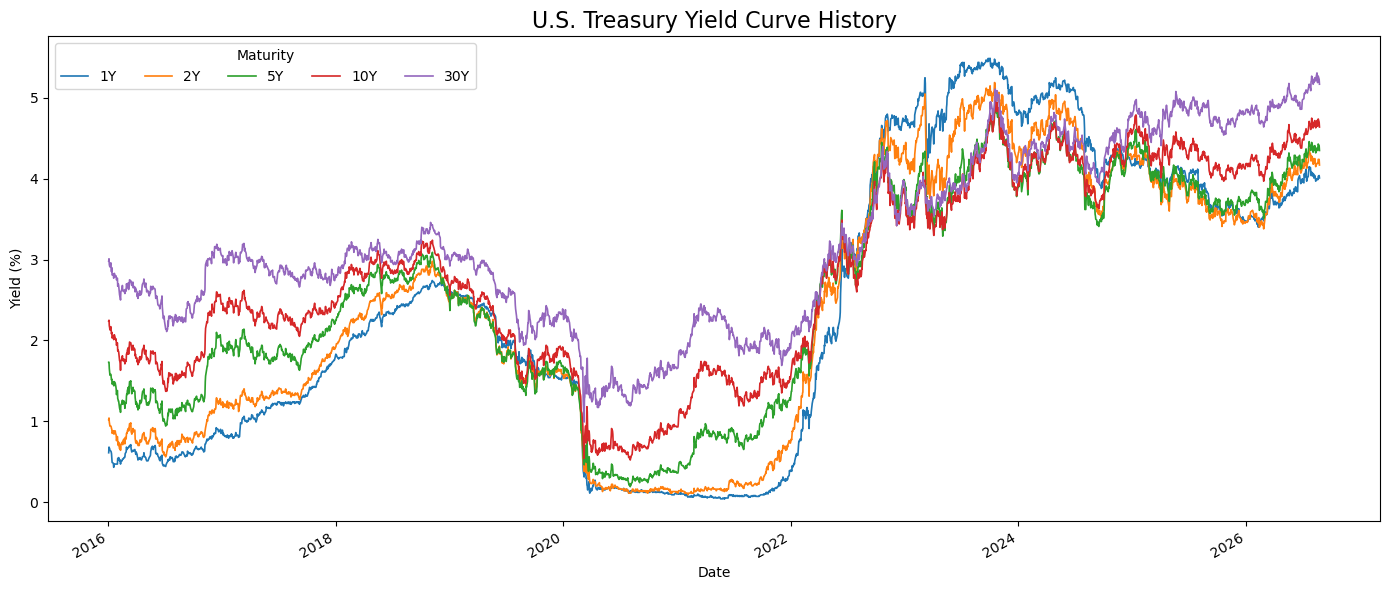

In [21]:
fig, ax = plt.subplots(figsize=(14, 6))

yields_pct.plot(
    ax=ax,
    linewidth=1.2
)

ax.set_title(
    "U.S. Treasury Yield Curve History",
    fontsize=16
)
ax.set_xlabel("Date")
ax.set_ylabel("Yield (%)")
ax.legend(title="Maturity", ncol=5)

plt.tight_layout()
plt.show()

### 4. Calculate Daily Yield Changes

FRED reports yields in percentage points. Daily changes are converted to basis points using

$$
\Delta y_t^{\text{bp}} = 100(y_t-y_{t-1}).
$$

For example, a move from 4.20% to 4.25% equals \(+5\) basis points.

`diff()` calculates the daily change. `dropna()` removes the first row because it has no previous observation.

PCA requires centered data, so we subtract each maturity's average daily change:

$$
X_{t,j}
=
\Delta y_{t,j}^{\text{bp}}
-
\overline{\Delta y_j^{\text{bp}}}.
$$

The average changes are close to zero. Daily volatility is approximately 4.1–5.6 basis points, with the 5Y yield the most volatile in this sample.

The minimum and maximum columns show the most extreme one-day moves.

In [22]:
# FRED gives yields in percentage points.
# Multiplying the differences by 100 converts them to basis points.

changes_bp = yields_pct.diff().dropna() * 100

# Subtract the average daily change from each maturity.
centered_changes = changes_bp - changes_bp.mean()

summary_statistics = pd.DataFrame({
    "mean_change_bp": changes_bp.mean(),
    "daily_volatility_bp": changes_bp.std(),
    "minimum_change_bp": changes_bp.min(),
    "maximum_change_bp": changes_bp.max(),
})

display(summary_statistics)
display(changes_bp.head())

,mean_change_bp,daily_volatility_bp,minimum_change_bp,maximum_change_bp
1Y,0.127772,4.121216,-60.0,34.0
2Y,0.118377,5.313046,-57.0,34.0
5Y,0.098459,5.562367,-32.0,31.0
10Y,0.090192,5.286469,-30.0,29.0
30Y,0.082300,5.020371,-31.0,29.0


,1Y,2Y,5Y,10Y,30Y
DATE,,,,,
2016-01-05,7.0,2.0,0.0,1.0,3.0
2016-01-06,-1.0,-5.0,-8.0,-7.0,-7.0
2016-01-07,-1.0,-3.0,-4.0,-2.0,-2.0
2016-01-08,-2.0,-2.0,-4.0,-3.0,-1.0
2016-01-11,-1.0,0.0,1.0,4.0,5.0


### 5. Correlation and Covariance

Correlation measures whether two maturities move together while ignoring the sizes of their movements:

$$
\rho_{ij}
=
\frac{\operatorname{Cov}(i,j)}
{\sigma_i\sigma_j}.
$$

Covariance preserves both the direction and size of their shared movements:

$$
\operatorname{Cov}(i,j)
=
\frac{1}{n-1}
\sum_{t=1}^{n}X_{t,i}X_{t,j}.
$$

### Left Graph: Correlation

All correlations are positive, confirming that Treasury yields usually move together.

Nearby maturities are most strongly related:

- 5Y and 10Y: 0.93
- 10Y and 30Y: 0.92

The 1Y and 30Y correlation is only 0.43. This weaker relationship allows the short and long ends to move differently, producing changes in Slope.

### Right Graph: Covariance

The diagonal cells show each maturity's variance in basis points squared.

The off-diagonal cells measure shared movement between two different maturities. The large middle-curve covariances show that the 2Y, 5Y, and 10Y yields often move strongly together.

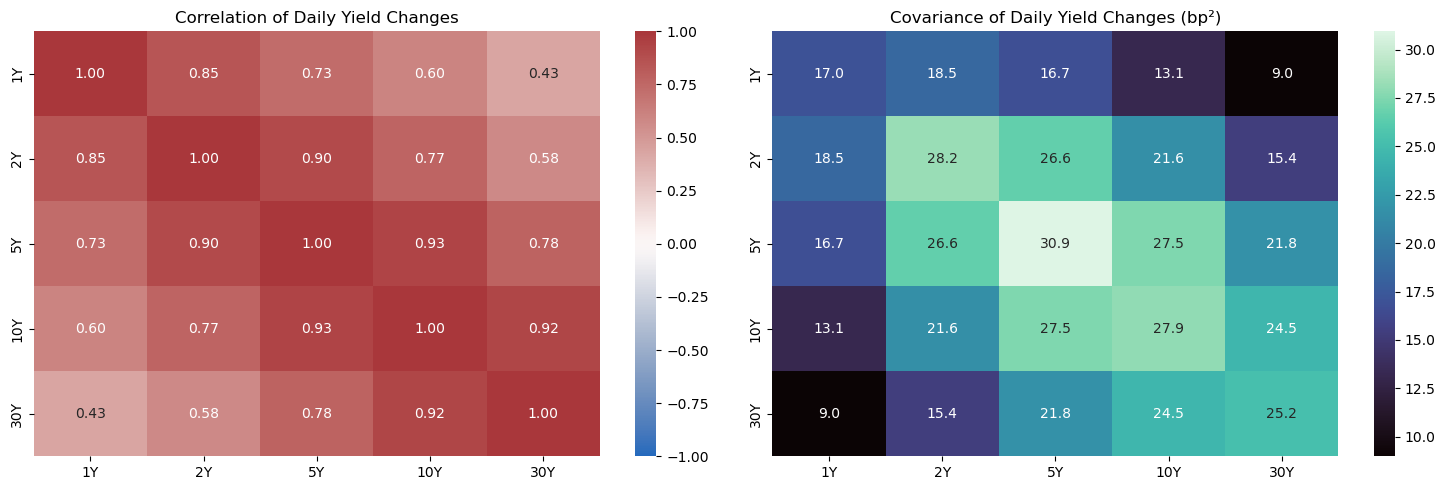

In [23]:
correlation_matrix = changes_bp.corr()
covariance_matrix_df = changes_bp.cov()

fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 5)
)

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    vmin=-1,
    vmax=1,
    ax=axes[0]
)

axes[0].set_title(
    "Correlation of Daily Yield Changes"
)

sns.heatmap(
    covariance_matrix_df,
    annot=True,
    fmt=".1f",
    cmap="mako",
    ax=axes[1]
)

axes[1].set_title(
    "Covariance of Daily Yield Changes (bp²)"
)

plt.tight_layout()
plt.show()

### 6. Apply SVD to the Covariance Matrix

The covariance matrix is decomposed using singular value decomposition:

$$
C = U\Lambda V^\top.
$$

Because the covariance matrix is symmetric and positive semidefinite, its left and right singular vectors describe the same directions.

In the code:

- The columns of `loadings` are the PCA loading vectors.
- `eigenvalues` measure how much variance each component explains.
- Larger eigenvalues indicate more important components.

The covariance matrix is reconstructed using

$$
\widehat C = U\Lambda V^\top.
$$

`assert_allclose()` verifies that the reconstructed matrix matches the original covariance matrix, allowing only tiny floating-point differences.

The passed check confirms that the SVD worked correctly.

In [24]:
covariance_matrix = covariance_matrix_df.to_numpy()

# Because the covariance matrix is symmetric,
# its SVD produces the PCA loading vectors and eigenvalues.

loadings, eigenvalues, loadings_transpose = np.linalg.svd(
    covariance_matrix
)

# Check that the SVD can reconstruct the covariance matrix.

reconstructed_covariance = (
    loadings
    @ np.diag(eigenvalues)
    @ loadings_transpose
)

np.testing.assert_allclose(
    covariance_matrix,
    reconstructed_covariance,
    atol=1e-10
)

print("Covariance reconstruction check passed.")

Covariance reconstruction check passed.


### 7. Orient and Measure the Components

A PCA loading vector can be multiplied by \(-1\) without changing the model. The direction's sign is arbitrary.

`orient_components()` chooses signs that are easier to interpret:

- PC1 is oriented so its average loading is positive.
- PC2 is oriented so it rises from short to long maturities.
- PC3 is oriented so the 5Y belly is above the short and long wings.

For eigenvalue \(\lambda_k\), the explained-variance ratio is

$$
\text{Explained Variance}_k
=
\frac{\lambda_k}{\sum_j \lambda_j}.
$$

The cumulative variance adds the explained variance of the components up to that point.

The results are:

- **PC1 — Level:** 82.53%
- **PC2 — Slope:** 13.05%
- **PC3 — Curvature:** 2.87%

Together, the first three components explain

$$
82.53\% + 13.05\% + 2.87\% = 98.45\%.
$$

Therefore, Level, Slope, and Curvature explain almost all daily yield-curve variation and exceed the 95% target.

In [25]:
def orient_components(loadings_matrix, tenor_years):
    oriented = loadings_matrix.copy()

    # Orient PC1 so that its average loading is positive.
    if oriented[:, 0].mean() < 0:
        oriented[:, 0] *= -1

    # Orient PC2 so that the long-end loading is above
    # the short-end loading.
    if oriented[-1, 1] - oriented[0, 1] < 0:
        oriented[:, 1] *= -1

    # Orient PC3 so that the 5Y "belly" is above the wings.
    five_year_position = np.argmin(
        np.abs(tenor_years - 5)
    )

    wing_average = (
        oriented[0, 2] + oriented[-1, 2]
    ) / 2

    if oriented[five_year_position, 2] < wing_average:
        oriented[:, 2] *= -1

    return oriented


loadings = orient_components(
    loadings,
    tenor_years
)

explained_variance = (
    eigenvalues / eigenvalues.sum()
)

cumulative_variance = np.cumsum(
    explained_variance
)

component_names = [
    "Level",
    "Slope",
    "Curvature",
    "PC4",
    "PC5",
]

variance_table = pd.DataFrame({
    "component": component_names,
    "eigenvalue_bp_squared": eigenvalues,
    "explained_variance": explained_variance,
    "cumulative_variance": cumulative_variance,
})

variance_table.index = [
    f"PC{i}"
    for i in range(1, len(eigenvalues) + 1)
]

display(
    variance_table.style.format({
        "eigenvalue_bp_squared": "{:.3f}",
        "explained_variance": "{:.2%}",
        "cumulative_variance": "{:.2%}",
    })
)

first_three_variance = cumulative_variance[2]

print(
    f"The first three components explain "
    f"{first_three_variance:.2%} of total variance."
)

if first_three_variance >= TARGET_VARIANCE:
    print("The first three components exceed the 95% target.")
else:
    print("The first three components do not exceed the 95% target.")

,component,eigenvalue_bp_squared,explained_variance,cumulative_variance
PC1,Level,106.709,82.53%,82.53%
PC2,Slope,16.875,13.05%,95.58%
PC3,Curvature,3.716,2.87%,98.45%
PC4,PC4,1.531,1.18%,99.63%
PC5,PC5,0.473,0.37%,100.00%


The first three components explain 98.45% of total variance.
The first three components exceed the 95% target.


### 8. Explained Variance and Loading Shapes

### Left Graph: Explained Variance

Each bar shows the percentage of variance explained by one component.

The black line shows cumulative explained variance:

- PC1 reaches 82.53%.
- PC1 and PC2 reach 95.58%.
- PC1, PC2, and PC3 reach 98.45%.

The first two components already cross the red 95% target. Adding PC3 produces an even more accurate representation.

### Right Graph: Component Loadings

Each line shows how strongly every maturity participates in one component.

- **Level:** all loadings are positive, so yields move in the same direction.
- **Slope:** short-end loadings are negative while long-end loadings are positive, causing the curve to tilt.
- **Curvature:** middle maturities have positive loadings while the short and long wings are negative, causing the curve to bend.

The maturity axis uses a logarithmic scale so the shorter maturities are not crowded together.

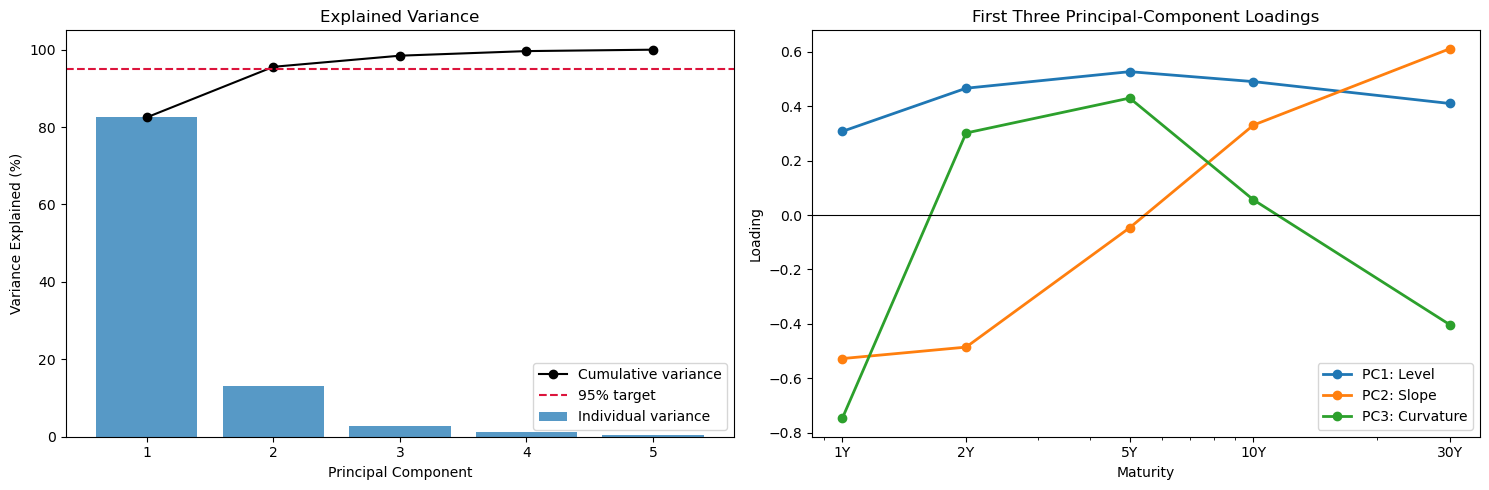

In [26]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 5)
)

component_numbers = np.arange(
    1,
    len(explained_variance) + 1
)

axes[0].bar(
    component_numbers,
    explained_variance * 100,
    alpha=0.75,
    label="Individual variance"
)

axes[0].plot(
    component_numbers,
    cumulative_variance * 100,
    color="black",
    marker="o",
    label="Cumulative variance"
)

axes[0].axhline(
    TARGET_VARIANCE * 100,
    color="crimson",
    linestyle="--",
    label="95% target"
)

axes[0].set_title("Explained Variance")
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Variance Explained (%)")
axes[0].set_xticks(component_numbers)
axes[0].legend()

factor_labels = [
    "PC1: Level",
    "PC2: Slope",
    "PC3: Curvature",
]

for component_number, label in enumerate(factor_labels):
    axes[1].plot(
        tenor_years,
        loadings[:, component_number],
        marker="o",
        linewidth=2,
        label=label,
    )

axes[1].axhline(
    0,
    color="black",
    linewidth=0.8
)

axes[1].set_title(
    "First Three Principal-Component Loadings"
)
axes[1].set_xlabel("Maturity")
axes[1].set_ylabel("Loading")
axes[1].set_xscale("log")
axes[1].set_xticks(tenor_years)
axes[1].set_xticklabels(tenor_labels)
axes[1].legend()

plt.tight_layout()
plt.show()

### 9. Inspect the Numerical Loadings

A loading measures how strongly each maturity participates in a component.

Each loading vector has length one:

$$
\sum_{j=1}^{5}v_{j,k}^2 = 1.
$$

### PC1: Level

Every loading is positive, so all maturities move together. The largest weights are around the 5Y and 10Y maturities.

### PC2: Slope

The loading changes from \(-0.53\) at 1Y to \(+0.61\) at 30Y. Therefore, the short and long ends move in opposite directions and the curve tilts.

### PC3: Curvature

The 1Y and 30Y loadings are negative, while the 2Y and 5Y loadings are positive. Therefore, the middle of the curve moves relative to the two wings.

Only the relative signs and magnitudes matter. Flipping every sign in one column would represent the same PCA direction.

In [27]:
loadings_table = pd.DataFrame(
    loadings[:, :3],
    index=tenor_labels,
    columns=[
        "PC1_Level",
        "PC2_Slope",
        "PC3_Curvature",
    ],
)

display(loadings_table)

,PC1_Level,PC2_Slope,PC3_Curvature
1Y,0.307721,-0.527774,-0.747237
2Y,0.466547,-0.485595,0.301888
5Y,0.527453,-0.046485,0.430311
10Y,0.490859,0.330991,0.055916
30Y,0.410479,0.611503,-0.402748


### 10. Calculate Daily Factor Scores

`X` is the centered daily-change matrix. Each daily curve movement is projected onto the PCA loading vectors:

$$
Z = XV,
$$

where \(V\) contains the loading vectors.

A factor score measures how strongly a component occurred on one particular day.

- A positive Level score means yields generally increased.
- A negative Level score means yields generally decreased.
- A positive Slope score means the long end increased relative to the short end.
- A positive Curvature score means the middle increased relative to the wings.

The graphs plot these scores through time.

Level has the largest movements because it explains the most variance. The factors became more volatile around 2020 and especially during 2022–2023, indicating larger and less stable daily curve movements.

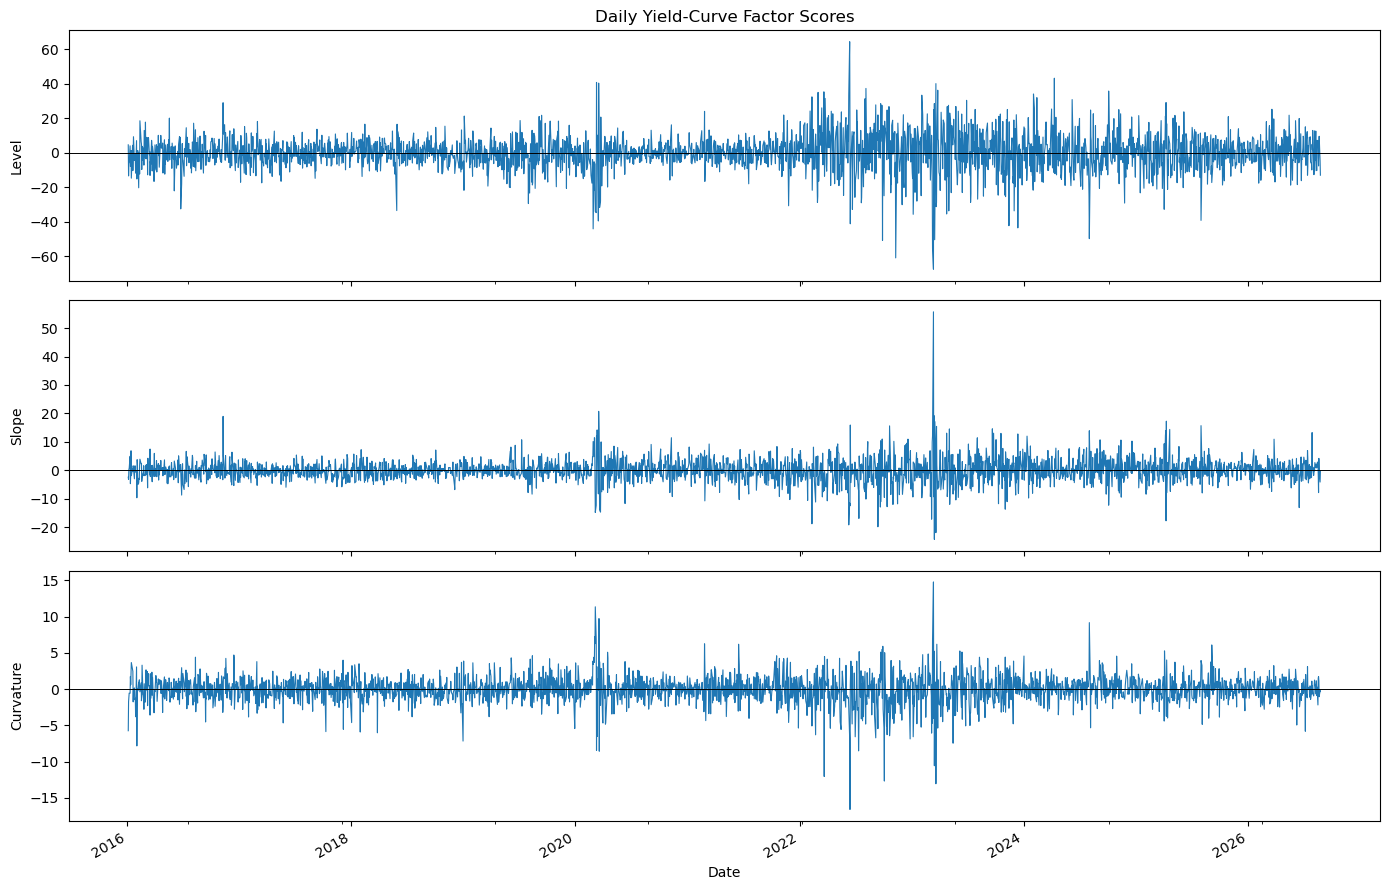

In [28]:
X = centered_changes.to_numpy()

# Project each daily curve change onto the PCA loadings.

factor_scores = X @ loadings

factor_scores_df = pd.DataFrame(
    factor_scores[:, :3],
    index=centered_changes.index,
    columns=[
        "Level",
        "Slope",
        "Curvature",
    ],
)

fig, axes = plt.subplots(
    3,
    1,
    figsize=(14, 9),
    sharex=True
)

for ax, factor in zip(
    axes,
    factor_scores_df.columns
):
    factor_scores_df[factor].plot(
        ax=ax,
        linewidth=0.8
    )
    
    ax.axhline(
        0,
        color="black",
        linewidth=0.7
    )
    
    ax.set_ylabel(factor)

axes[0].set_title(
    "Daily Yield-Curve Factor Scores"
)

axes[-1].set_xlabel("Date")

plt.tight_layout()
plt.show()

### 11. Convert Loadings into Realistic Factor Shocks

Loadings describe the shape of a component but not its normal size.

To express each component as a basis-point shock, multiply its loading vector by its standard deviation:

$$
\text{One-sigma shock}_k
=
\sqrt{\lambda_k}\,v_k.
$$

This works because \(\lambda_k\) is the factor's variance, so \(\sqrt{\lambda_k}\) is its standard deviation.

The results show that:

- A typical Level shock raises all maturities by approximately 3.2–5.4 basis points.
- A typical Slope shock lowers the 1Y yield by about 2.2 basis points while raising the 30Y yield by about 2.5 basis points.
- A typical Curvature shock raises the 2Y–5Y belly while lowering the short and long wings.

The sign could be reversed and still represent the same factor moving in the opposite direction.

In [29]:
# A one-standard-deviation factor shock equals:
# loading × square root of the factor's eigenvalue.

one_standard_deviation_shocks = (
    loadings[:, :3]
    * np.sqrt(eigenvalues[:3])
)

shock_table = pd.DataFrame(
    one_standard_deviation_shocks,
    index=tenor_labels,
    columns=[
        "Level_shock_bp",
        "Slope_shock_bp",
        "Curvature_shock_bp",
    ],
)

display(shock_table)

,Level_shock_bp,Slope_shock_bp,Curvature_shock_bp
1Y,3.178752,-2.168050,-1.440414
2Y,4.819422,-1.994782,0.581936
5Y,5.448577,-0.190958,0.829490
10Y,5.070565,1.359680,0.107786
30Y,4.240244,2.512000,-0.776358


### 12. Reconstruct the Data with Fewer Components

Using only the first \(k\) components, the reconstructed daily changes are

$$
\widehat X_k = Z_kV_k^\top.
$$

The reconstruction is compared with the original data using three measurements:

- **RMSE:** the typical reconstruction error in basis points.
- **Maximum absolute error:** the largest single reconstruction mistake.
- **Variance retained:** the percentage of the original variation preserved.

With three components, the model:

- Retains 98.45% of variance.
- Has an RMSE of only 0.633 basis points.
- Has a maximum error of 4.91 basis points.

Using all five components gives zero reconstruction error because all five original dimensions have been retained.

In [30]:
reconstruction_results = []
reconstructions = {}

for number_of_components in range(
    1,
    len(tenor_labels) + 1
):
    reconstructed_changes = (
        factor_scores[:, :number_of_components]
        @ loadings[:, :number_of_components].T
    )

    reconstructions[number_of_components] = (
        reconstructed_changes
    )

    reconstruction_error = (
        X - reconstructed_changes
    )

    rmse = np.sqrt(
        np.mean(reconstruction_error ** 2)
    )

    maximum_error = np.max(
        np.abs(reconstruction_error)
    )

    reconstruction_results.append({
        "number_of_components": number_of_components,
        "rmse_bp": rmse,
        "maximum_absolute_error_bp": maximum_error,
        "variance_retained": cumulative_variance[
            number_of_components - 1
        ],
    })


reconstruction_table = pd.DataFrame(
    reconstruction_results
).set_index("number_of_components")

display(
    reconstruction_table.style.format({
        "rmse_bp": "{:.4f}",
        "maximum_absolute_error_bp": "{:.4f}",
        "variance_retained": "{:.2%}",
    })
)

,rmse_bp,maximum_absolute_error_bp,variance_retained
number_of_components,,,
1,2.1254,39.3835,82.53%
2,1.0694,14.0608,95.58%
3,0.6330,4.9066,98.45%
4,0.3076,2.9367,99.63%
5,0.0000,0.0000,100.00%


### 13. Visualize Reconstruction on the Largest-Move Day

The code finds the day with the largest total yield-curve movement using the Euclidean norm:

$$
\lVert X_t\rVert_2
=
\sqrt{\sum_j X_{t,j}^2}.
$$

The largest move occurred on March 13, 2023.

The black line shows the actual demeaned daily curve movement.

- The one-component reconstruction captures only a broad downward Level move and misses the curve's steep shape.
- The two-component reconstruction adds Slope and becomes much closer, although it overshoots the 30Y movement.
- The three-component reconstruction adds Curvature and nearly overlaps the actual movement at every maturity.

This demonstrates why Level alone is insufficient but Level, Slope, and Curvature work well together.

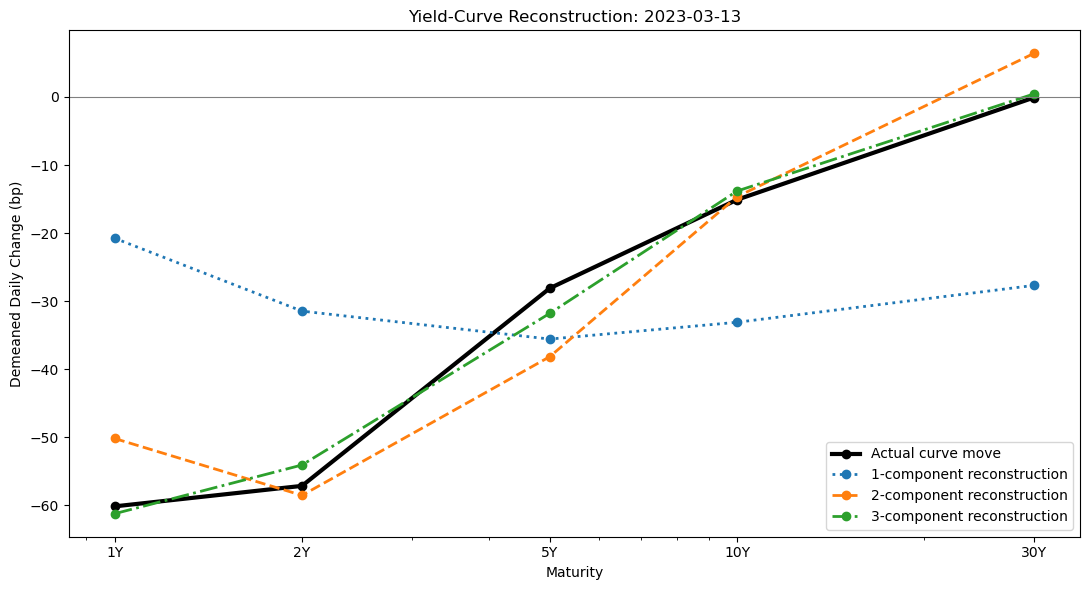

In [31]:
# Find the day with the largest total curve movement.

event_position = np.argmax(
    np.linalg.norm(X, axis=1)
)

event_date = centered_changes.index[
    event_position
]

fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(
    tenor_years,
    X[event_position],
    color="black",
    marker="o",
    linewidth=3,
    label="Actual curve move",
)

for number_of_components, line_style in zip(
    [1, 2, 3],
    [":", "--", "-."]
):
    ax.plot(
        tenor_years,
        reconstructions[number_of_components][event_position],
        marker="o",
        linestyle=line_style,
        linewidth=2,
        label=(
            f"{number_of_components}-component "
            f"reconstruction"
        ),
    )

ax.axhline(
    0,
    color="grey",
    linewidth=0.8
)

ax.set_title(
    f"Yield-Curve Reconstruction: {event_date.date()}"
)
ax.set_xlabel("Maturity")
ax.set_ylabel("Demeaned Daily Change (bp)")
ax.set_xscale("log")
ax.set_xticks(tenor_years)
ax.set_xticklabels(tenor_labels)
ax.legend()

plt.tight_layout()
plt.show()

### 14. Connect Covariance PCA with Direct SVD

The earlier method applied SVD to the covariance matrix. *Data-Driven Science and Engineering* often applies SVD directly to the centered data matrix:

$$
X = U\Sigma V^\top.
$$

The covariance matrix is

$$
C
=
\frac{X^\top X}{n-1}.
$$

Substituting the SVD of \(X\) gives

$$
C
=
V\frac{\Sigma^2}{n-1}V^\top.
$$

Therefore, the covariance eigenvalues satisfy

$$
\lambda_k
=
\frac{\sigma_k^2}{n-1}.
$$

The two columns in the table match exactly. `assert_allclose()` confirms this numerically.

Therefore, applying SVD directly to the centered data and applying SVD to its covariance matrix are two equivalent ways to perform PCA.

In [32]:
# Confirm that applying SVD directly to the centered data
# gives the same eigenvalues as applying SVD to the covariance matrix.

U_data, singular_values_data, Vt_data = np.linalg.svd(
    X,
    full_matrices=False
)

eigenvalues_from_data_svd = (
    singular_values_data ** 2
    / (len(X) - 1)
)

comparison_table = pd.DataFrame({
    "covariance_SVD_eigenvalue": eigenvalues,
    "data_SVD_eigenvalue": eigenvalues_from_data_svd,
})

comparison_table.index = [
    f"PC{i}"
    for i in range(1, len(eigenvalues) + 1)
]

display(comparison_table)

np.testing.assert_allclose(
    eigenvalues,
    eigenvalues_from_data_svd,
    rtol=1e-10,
    atol=1e-10,
)

print("Both SVD methods produce the same eigenvalues.")

,covariance_SVD_eigenvalue,data_SVD_eigenvalue
PC1,106.708570,106.708570
PC2,16.874936,16.874936
PC3,3.715845,3.715845
PC4,1.531155,1.531155
PC5,0.473180,0.473180


Both SVD methods produce the same eigenvalues.
